# 1. Perkenalan Dataset

**Nama:** ASEP HARYANA SAPUTRA  
**Dataset:** Poker Hand - UCI Machine Learning Repository  
**URL Sumber:** [UCI Poker Hand](https://archive.ics.uci.edu/dataset/158/poker+hand)


**Deskripsi Dataset:**
Dataset Poker Hand terdiri dari 1.025.010 instance dengan 10 fitur input dan 1 label kelas. Tantangan utamanya adalah class imbalance ekstrem.

# 2. Import Library

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')

Libraries loaded successfully.


# 3. Memuat Dataset

In [6]:
# Column definitions berdasarkan poker-hand.names
COLUMNS = [
    'S1', 'C1',  # Suit & Rank card 1
    'S2', 'C2',  # Suit & Rank card 2
    'S3', 'C3',  # Suit & Rank card 3
    'S4', 'C4',  # Suit & Rank card 4
    'S5', 'C5',  # Suit & Rank card 5
    'CLASS'      # Target: Poker Hand (0-9)
]

CLASS_NAMES = {
    0: 'Nothing',
    1: 'One Pair',
    2: 'Two Pairs',
    3: 'Three of a Kind',
    4: 'Straight',
    5: 'Flush',
    6: 'Full House',
    7: 'Four of a Kind',
    8: 'Straight Flush',
    9: 'Royal Flush'
}

RAW_DIR = './pokerhand_raw'

# Load training set
df_train = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-training-true.data'),
    header=None,
    names=COLUMNS
)

# Sample 100k rows dari testing set untuk validasi EDA (full set = 1M rows)
df_test_sample = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-testing.data'),
    header=None,
    names=COLUMNS,
    nrows=100_000
)

print(f'Training shape: {df_train.shape}')
print(f'Test sample shape: {df_test_sample.shape}')

Training shape: (25010, 11)
Test sample shape: (100000, 11)


# 4. Exploratory Data Analysis (EDA)

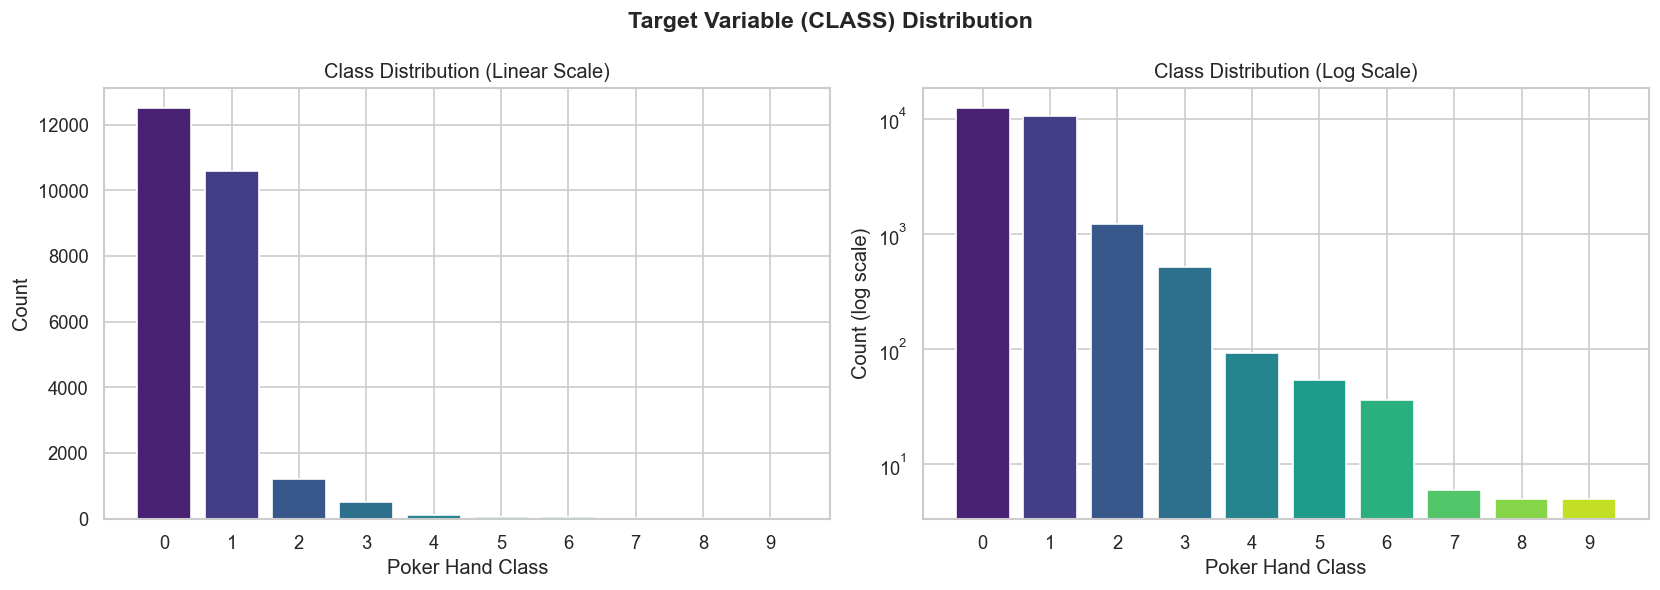


Class counts:
  Class 0 (Nothing): 12493 (49.95%)
  Class 1 (One Pair): 10599 (42.38%)
  Class 2 (Two Pairs): 1206 (4.82%)
  Class 3 (Three of a Kind): 513 (2.05%)
  Class 4 (Straight): 93 (0.37%)
  Class 5 (Flush): 54 (0.22%)
  Class 6 (Full House): 36 (0.14%)
  Class 7 (Four of a Kind): 6 (0.02%)
  Class 8 (Straight Flush): 5 (0.02%)
  Class 9 (Royal Flush): 5 (0.02%)


In [12]:
# ============================
# 3.1 Class Distribution
# ============================
class_counts = df_train['CLASS'].value_counts().sort_index()
class_labels = [f'{k}: {CLASS_NAMES[k]}' for k in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[0].set_xlabel('Poker Hand Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Linear Scale)')
axes[0].set_xticks(range(10))

# Log scale — reveals rare classes
axes[1].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[1].set_yscale('log')
axes[1].set_xlabel('Poker Hand Class')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_xticks(range(10))

plt.suptitle('Target Variable (CLASS) Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClass counts:')
for k, v in class_counts.items():
    print(f'  Class {k} ({CLASS_NAMES[k]}): {v} ({v/len(df_train)*100:.2f}%)')

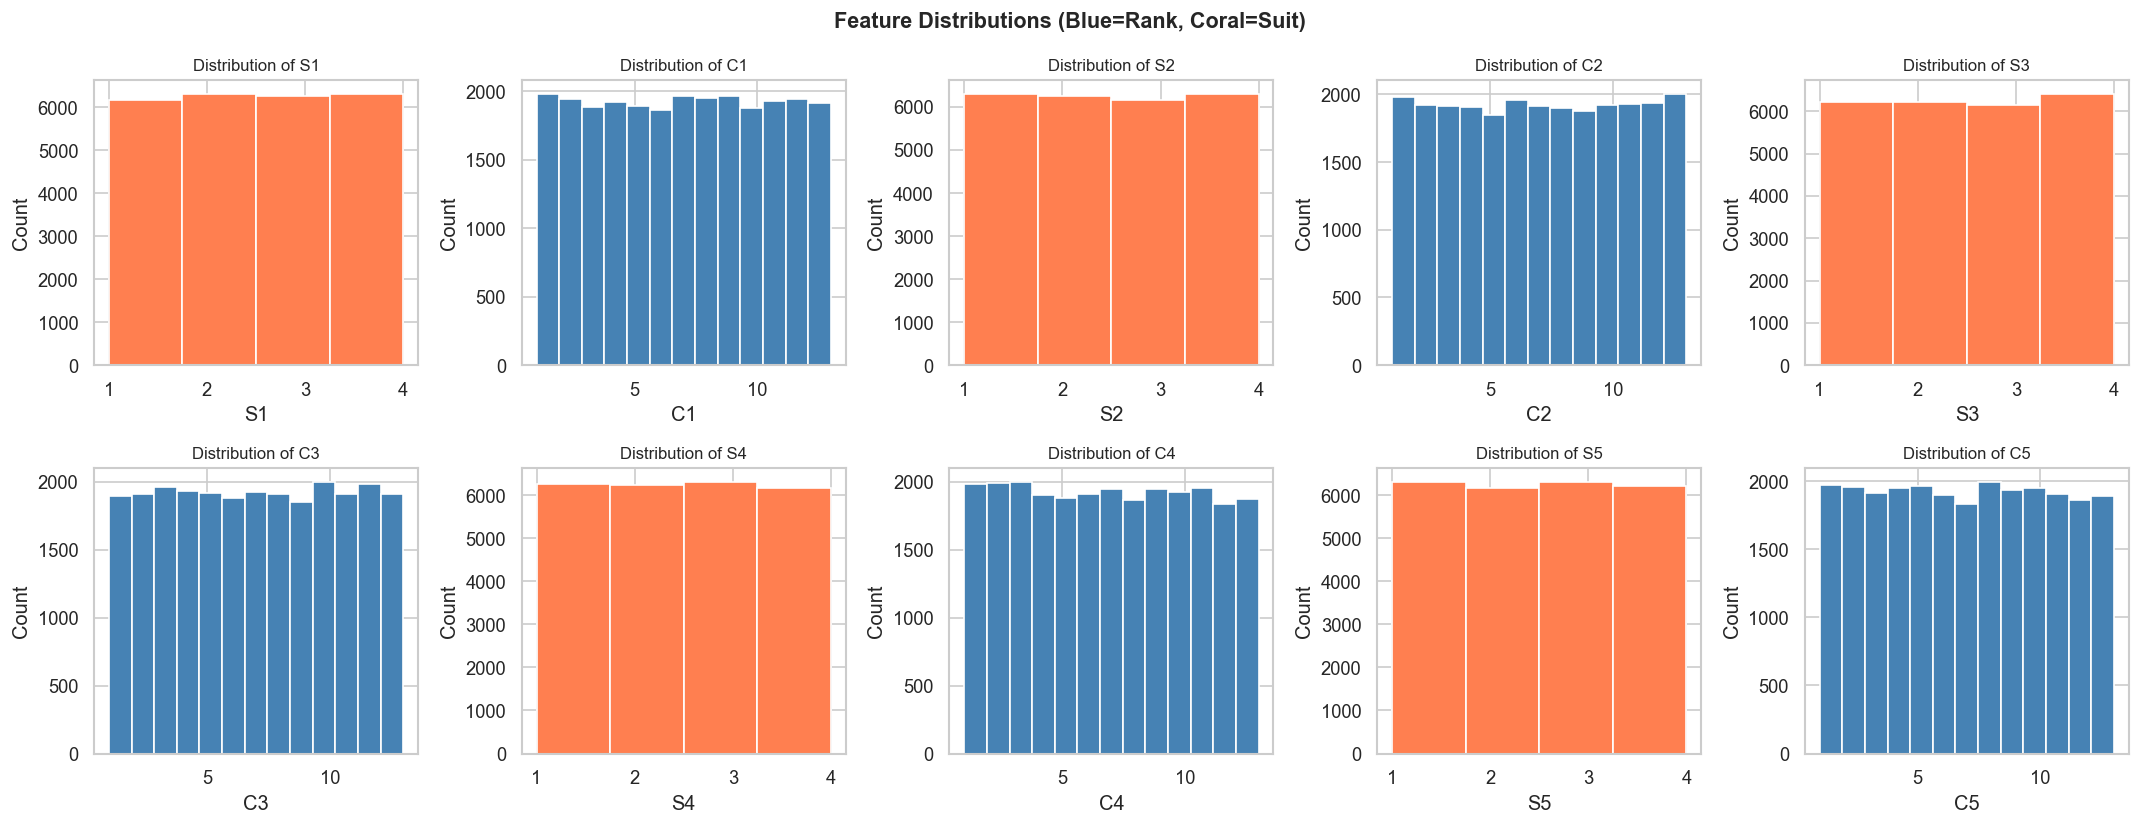

In [13]:
# ============================
# 3.2 Distribusi Fitur Numerik
# ============================
feature_cols = [c for c in COLUMNS if c != 'CLASS']
suit_cols = ['S1', 'S2', 'S3', 'S4', 'S5']
rank_cols = ['C1', 'C2', 'C3', 'C4', 'C5']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df_train[col], bins=df_train[col].nunique(), edgecolor='white', 
                 color='steelblue' if col.startswith('C') else 'coral')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions (Blue=Rank, Coral=Suit)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

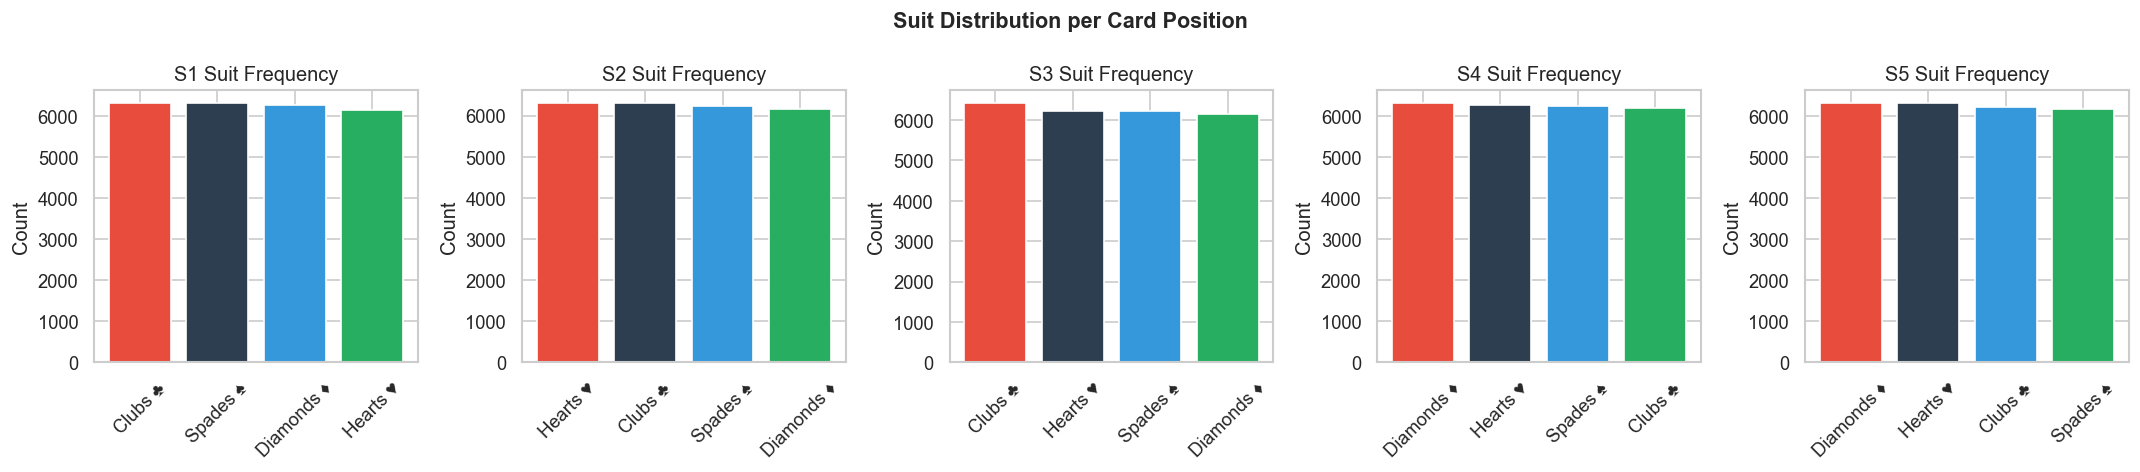

In [14]:
# ============================
# 3.3 Analisis Fitur Kategorikal (Suit)
# Suit values: 1=Hearts, 2=Spades, 3=Diamonds, 4=Clubs
# ============================
suit_map = {1: 'Hearts ♥', 2: 'Spades ♠', 3: 'Diamonds ♦', 4: 'Clubs ♣'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(suit_cols):
    counts = df_train[col].map(suit_map).value_counts()
    axes[i].bar(counts.index, counts.values, color=['#e74c3c', '#2c3e50', '#3498db', '#27ae60'])
    axes[i].set_title(f'{col} Suit Frequency')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

plt.suptitle('Suit Distribution per Card Position', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

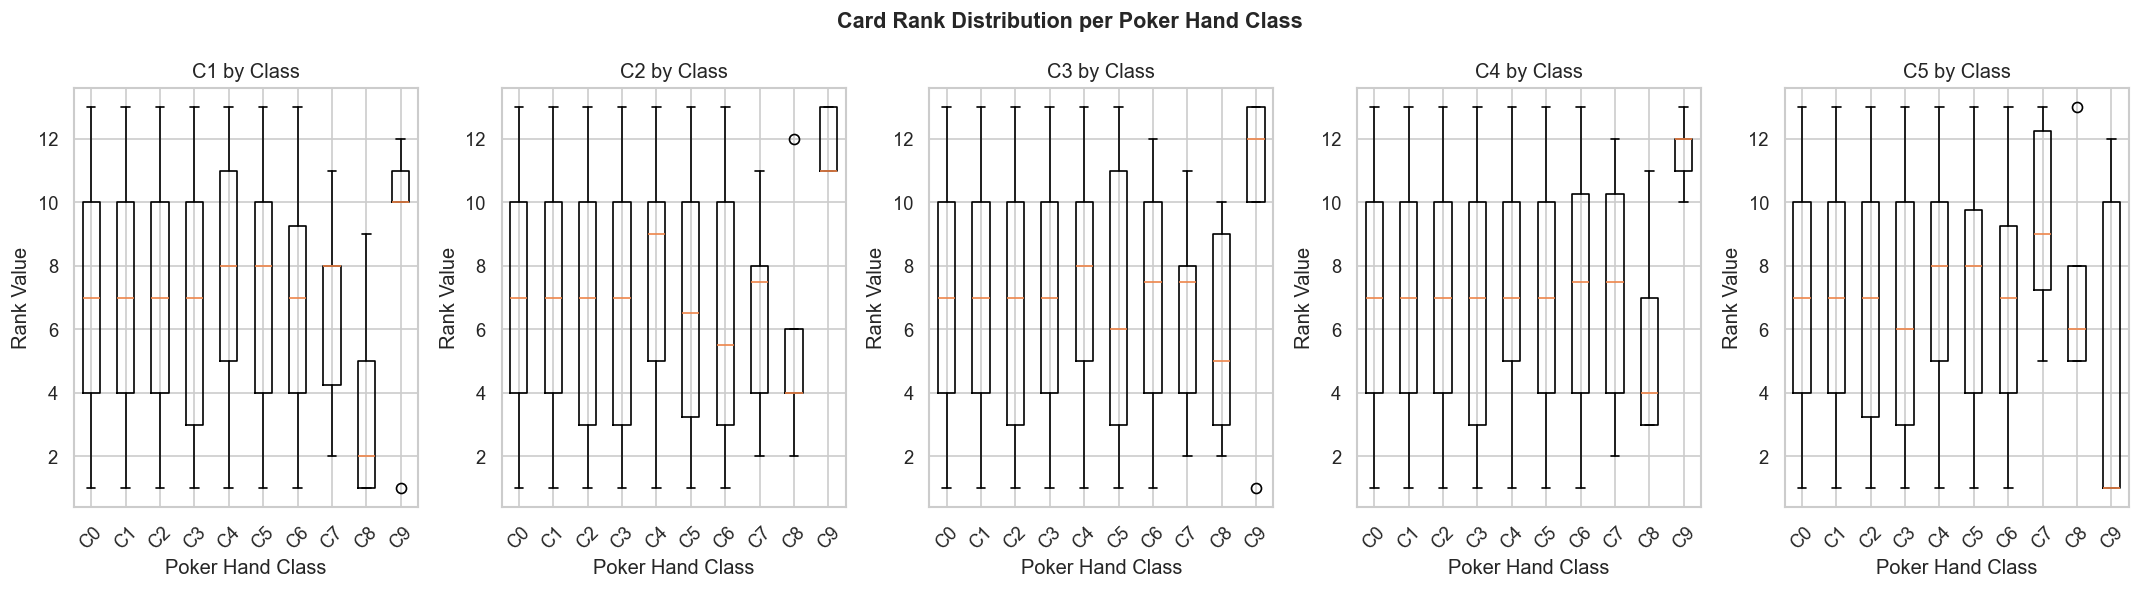

In [16]:
# ============================
# 3.5 Boxplot Rank per Class
# ============================
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(rank_cols):
    # Sample untuk kecepatan plotting
    sample = df_train.sample(min(5000, len(df_train)), random_state=42)
    class_order = sorted(df_train['CLASS'].unique())
    sample['CLASS_NAME'] = sample['CLASS'].map(lambda x: f'C{x}')
    axes[i].boxplot(
        [df_train.loc[df_train['CLASS'] == c, col].values for c in class_order],
        labels=[f'C{c}' for c in class_order]
    )
    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('Poker Hand Class')
    axes[i].set_ylabel('Rank Value')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Card Rank Distribution per Poker Hand Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

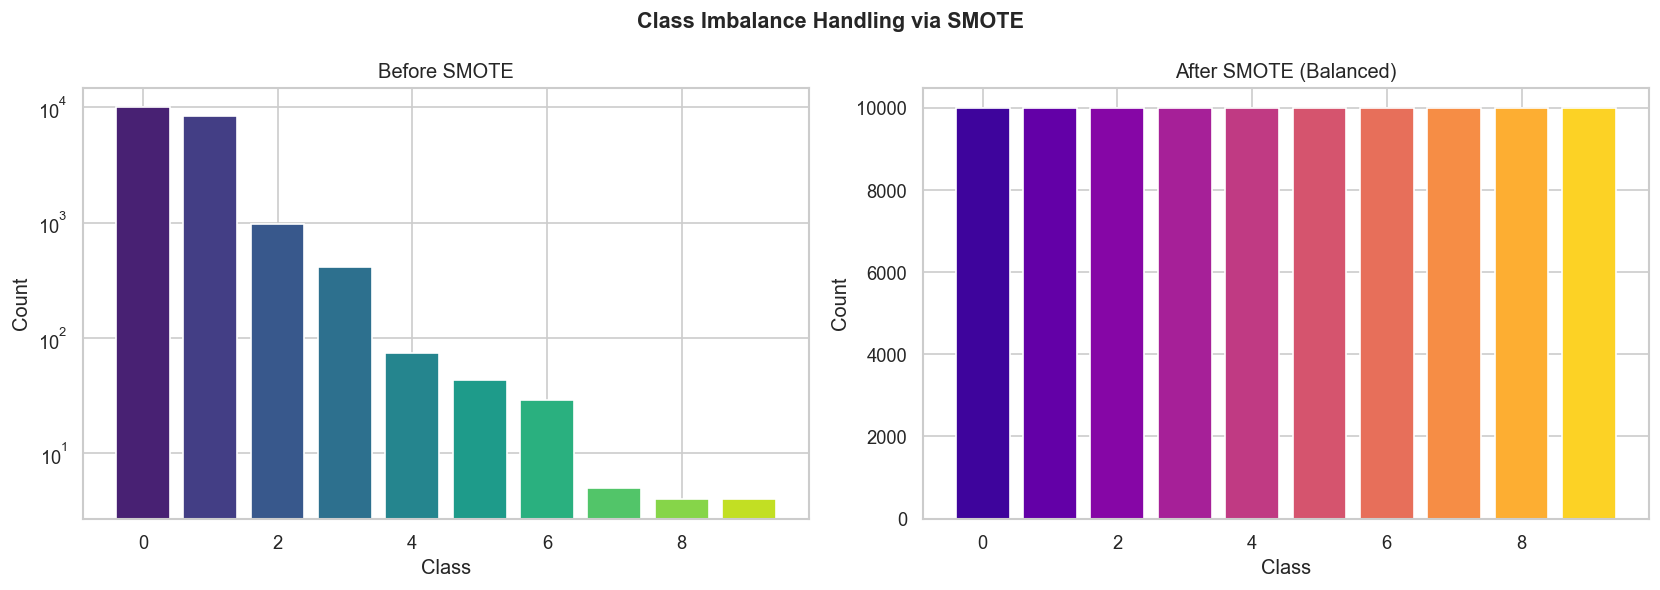

In [26]:
# Visualisasi sebelum vs sesudah SMOTE
before = Counter(y_train)
after  = Counter(y_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(before.keys())
axes[0].bar(classes, [before[c] for c in classes], color=sns.color_palette('viridis', 10))
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

axes[1].bar(classes, [after[c] for c in classes], color=sns.color_palette('plasma', 10))
axes[1].set_title('After SMOTE (Balanced)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.suptitle('Class Imbalance Handling via SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Data Preprocessing

## 5.1 Menghapus atau Menangani Data Kosong (Missing Values)

In [10]:
# ============================
# Cek Missing Values
# ============================
missing = df_train.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
CLASS    0
dtype: int64

Total missing: 0


In [19]:
# ============================
# 4.1 Handle Missing Values
# ============================
# Berdasarkan EDA: dataset ini TIDAK memiliki missing values.
# Namun kita tetap validasi dan log.
assert df_train.isnull().sum().sum() == 0, 'Unexpected missing values found!'
print('✅ No missing values — no imputation needed.')

✅ No missing values — no imputation needed.


## 5.2 Menghapus Data Duplikat

In [11]:
# ============================
# Cek Duplicate
# ============================
n_dup = df_train.duplicated().sum()
print(f'Duplicate rows: {n_dup}')
print(f'Percentage: {n_dup / len(df_train) * 100:.2f}%')

Duplicate rows: 2
Percentage: 0.01%


## 5.3 Normalisasi atau Standarisasi Fitur

*Menggunakan StandardScaler untuk penskalaan fitur numerik.*

## 5.4 Deteksi dan Penanganan Outlier

*Dilakukan pengecekan rentang nilai statis sesuai aturan permainan poker.*

## 5.5 Encoding Data Kategorikal

*Encoding One-Hot diterapkan pada fitur Suit.*

## 5.6 Binning (Pengelompokan Data)

*Binning tidak diperlukan untuk dataset ini karena semua fitur bersifat diskrit atau ordinal.*

# 6. Modelling

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi Model
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight="balanced", 
    random_state=42
)

# Latih Model
print("Training model...")
rf_model.fit(df_train.drop("CLASS", axis=1), df_train["CLASS"])
print("Model trained.")

# 7. Evaluasi

In [ ]:
# Prediksi pada data sample testing
y_pred = rf_model.predict(df_test_sample.drop("CLASS", axis=1))
y_true = df_test_sample["CLASS"]

# Akurasi
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# Classification Report
print("
Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()